In [ ]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & PATH CONFIGURATION
# DESCRIPTION: Configure paths for local project structure.
#              Update BASE_DIR if running from a different location.
# ==============================================================================

import os
import sys

# Auto-detect project root (works locally and in Colab)
try:
    # Local: go up from notebooks/ to project root
    BASE_DIR = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
except NameError:
    # Colab / interactive: set manually
    BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

MODEL_PATH = os.path.join(BASE_DIR, "models", "stage3", "stage3_efficientnet_finetuned_best.keras")
VAL_DIR    = os.path.join(BASE_DIR, "data", "stage3_disease", "val")

print(f"📁 Project Root : {BASE_DIR}")
print(f"🤖 Model Path   : {MODEL_PATH}")
print(f"📂 Val Dir      : {VAL_DIR}")

# Validate
for label, path in [("Model", MODEL_PATH), ("Val Dir", VAL_DIR)]:
    status = "✅ Found" if os.path.exists(path) else "❌ NOT FOUND — check your path"
    print(f"  {label}: {status}")


In [ ]:
# ==============================================================================
# CELL 1: IMPORTS & VISUALIZATION STYLE
# ==============================================================================

import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.2)

print(f"TensorFlow Version: {tf.__version__}")
print("✅ Environment ready.")


In [ ]:
# ==============================================================================
# CELL 2: LOAD MODEL & DATA (5-CLASS — PRODUCTION CONFIG)
# DESCRIPTION: Loads EfficientNetB4 model and validation data generator.
#              CLASS_NAMES are loaded dynamically from the dataset directory.
# ==============================================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🤖 Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded.")

print("\n📂 Loading validation data...")
val_datagen = ImageDataGenerator()
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False  # CRITICAL: must be False for correct label alignment
)

# Load class names dynamically from dataset — always in sync with training
CLASS_NAMES = list(val_generator.class_indices.keys())
print(f"\n✅ Data ready. {val_generator.samples} images | {len(CLASS_NAMES)} classes:")
for i, name in enumerate(CLASS_NAMES):
    print(f"   {i}. {name}")


In [ ]:
# ==============================================================================
# CELL 3: FULL INFERENCE & CLASSIFICATION REPORT
# ==============================================================================

print("⏳ Running inference on validation set...\n")

val_generator.reset()
predictions = model.predict(val_generator, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

print("\n" + "="*60)
print("  📄 STAGE 3 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


In [ ]:
# ==============================================================================
# CELL 4: CONFUSION MATRIX
# ==============================================================================

print("📊 Generating Confusion Matrix...")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    annot_kws={"size": 14, "weight": "bold"},
    linewidths=1, linecolor="black"
)
plt.title("Stage 3: Dental Diseases — Confusion Matrix", fontsize=16, fontweight="bold", pad=20)
plt.ylabel("Actual Clinical Diagnosis", fontsize=12, fontweight="bold")
plt.xlabel("AI Predicted Diagnosis", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()


🌟 Generating Explainable AI Visualization...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


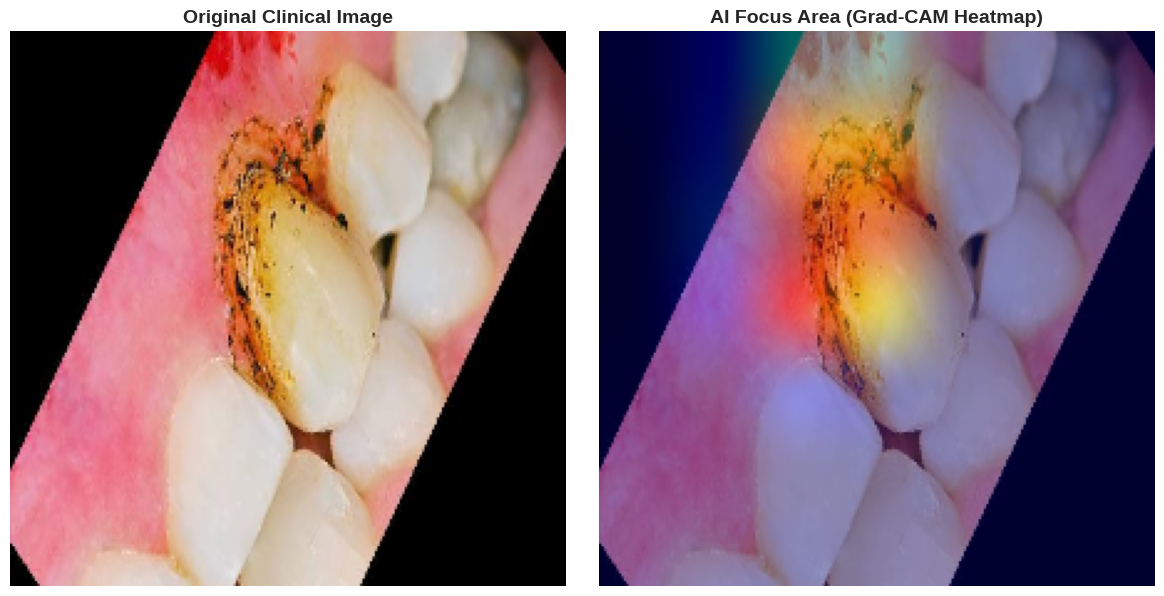

In [9]:
# ==============================================================================
# CELL 5: EXPLAINABLE AI (XAI) - GRADIENT-WEIGHTED CLASS ACTIVATION MAPPING
# DESCRIPTION: Uses Grad-CAM to generate visual explanations for model decisions.
#              Highlights the regions of the image that strongly influenced the prediction.
# ==============================================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv"):
    """Generates the Grad-CAM heatmap for a specific image array."""
    # Create a sub-model that outputs the feature map of the last conv layer
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Compute gradients of the predicted class with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature map by the computed gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.6):
    """Overlays the heatmap onto the original image and plots the result."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Convert heatmap to RGB format
    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Resize heatmap to match image dimensions
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap onto the original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Clinical Image", fontsize=14, fontweight='bold')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("AI Focus Area (Grad-CAM Heatmap)", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- DEMONSTRATION ---
print("🌟 Generating Explainable AI Visualization...")
# Select a specific image from the dataset (e.g., the first image)
sample_image_path = val_generator.filepaths[0]

# Prepare the image
img = image.load_img(sample_image_path, target_size=(224, 224))
img_array = np.expand_dims(image.img_to_array(img), axis=0)

# Generate and display Grad-CAM
heatmap = make_gradcam_heatmap(img_array, model)
display_gradcam(sample_image_path, heatmap)

🩺 Launching Virtual AI Clinic Dashboard...



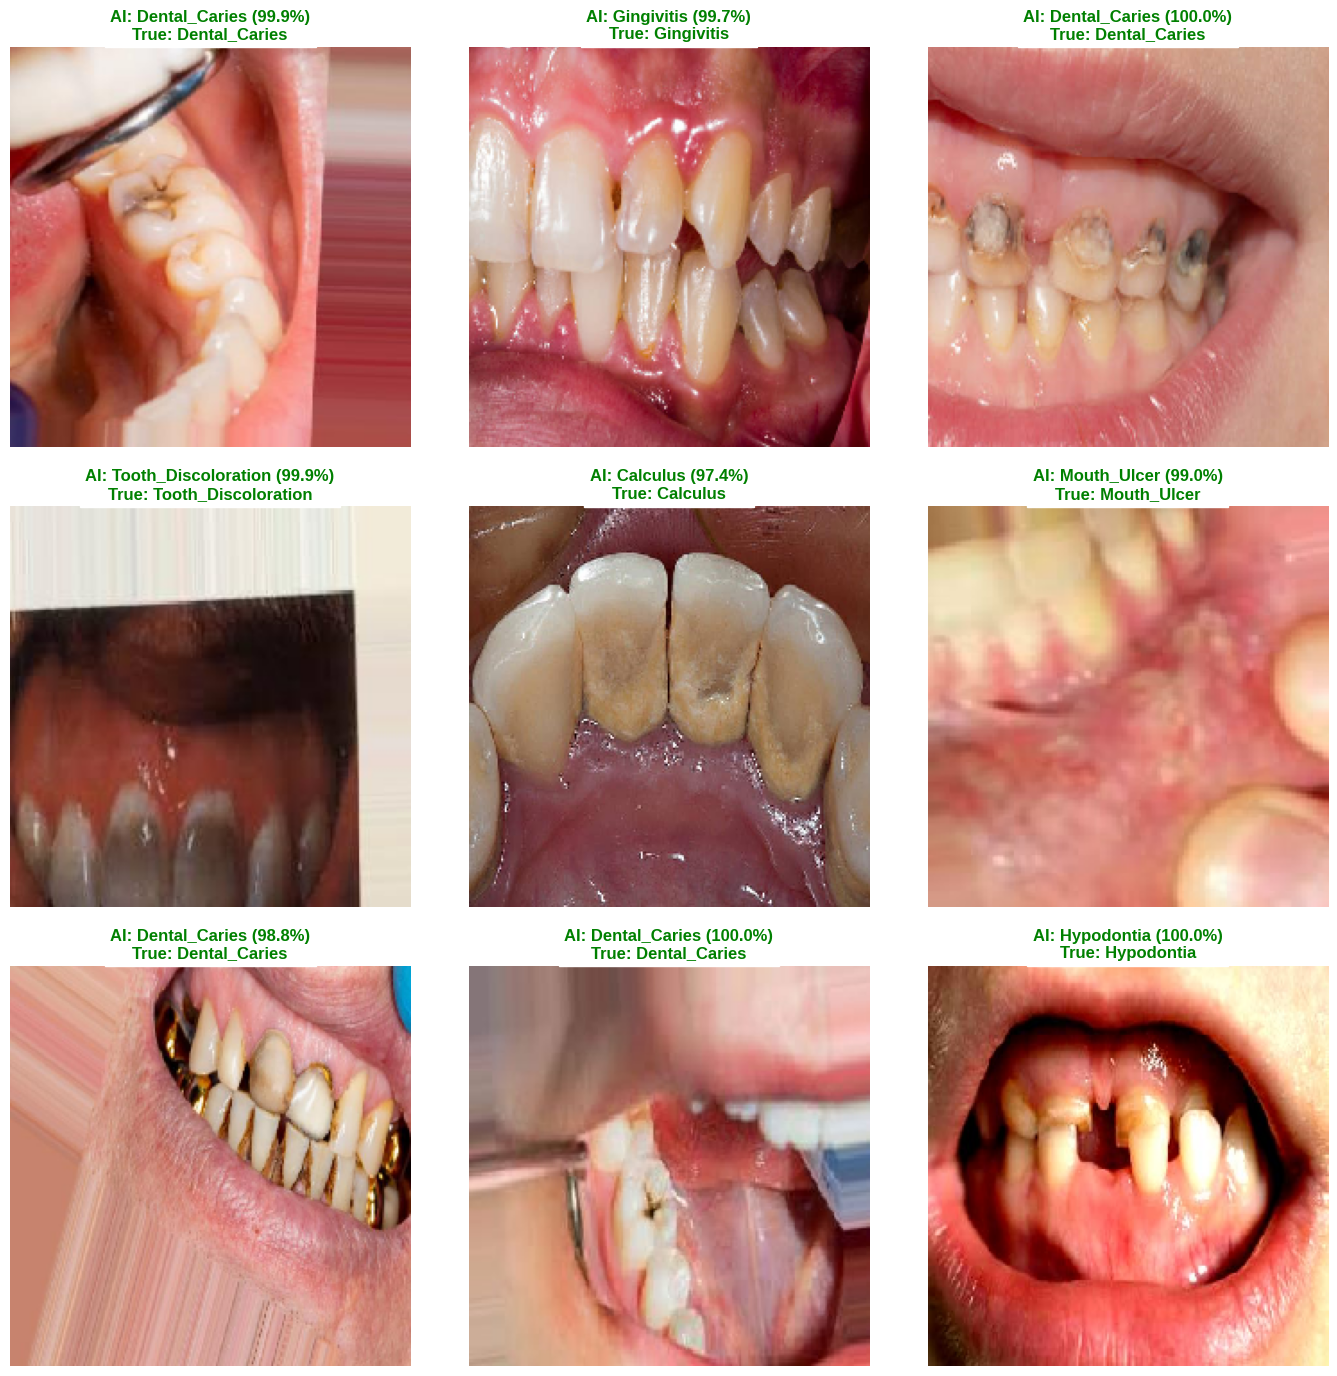

In [11]:
# ==============================================================================
# CELL 6: VIRTUAL CLINIC DASHBOARD (REAL-WORLD SIMULATION)
# DESCRIPTION: Randomly selects 9 images from the evaluation set and displays
#              them alongside the AI's prediction, confidence level, and true label.
# ==============================================================================

print("🩺 Launching Virtual AI Clinic Dashboard...\n")

plt.figure(figsize=(14, 14))

# Randomly select 9 distinct patient images
random_indices = random.sample(range(len(val_generator.filepaths)), 9)

for i, idx in enumerate(random_indices):
    img_path = val_generator.filepaths[idx]
    true_label = CLASS_NAMES[val_generator.classes[idx]]

    # Prepare image for inference
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = np.expand_dims(image.img_to_array(img), axis=0)

    # Model Prediction
    preds = model.predict(img_array, verbose=0)
    pred_index = np.argmax(preds[0])
    pred_label = CLASS_NAMES[pred_index]
    confidence = np.max(preds[0]) * 100

    # Plotting
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')

    # Color coding: Green for correct diagnosis, Red for misdiagnosis
    text_color = 'green' if true_label == pred_label else 'red'

    title_text = f"AI: {pred_label} ({confidence:.1f}%)\nTrue: {true_label}"
    plt.title(title_text, color=text_color, fontsize=12, fontweight='bold', backgroundcolor='white')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 7: TRAINING HISTORY CURVES
# DESCRIPTION: Loads the saved training history from train_stage3.py output
#              and plots Accuracy & Loss curves for both training phases.
# NOTE: Run train_stage3.py first — it saves history to reports/training_history.json
# ==============================================================================
import json as _json

HISTORY_PATH = os.path.join(BASE_DIR, "reports", "training_history.json")

def plot_training_history(hist_dict, title="Model Training History"):
    """Plots Accuracy and Loss curves from a history dictionary."""
    acc        = hist_dict["accuracy"]
    val_acc    = hist_dict["val_accuracy"]
    loss       = hist_dict["loss"]
    val_loss   = hist_dict["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(16, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc,     "b-o", label="Training Accuracy")
    plt.plot(epochs_range, val_acc, "r-o", label="Validation Accuracy")
    plt.title(f"{title} — Accuracy", fontsize=14, fontweight="bold")
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.7)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss,     "b-o", label="Training Loss")
    plt.plot(epochs_range, val_loss, "r-o", label="Validation Loss")
    plt.title(f"{title} — Loss", fontsize=14, fontweight="bold")
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

# Load and plot
if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH, "r") as f:
        history_data = _json.load(f)

    print("📊 Phase 1 — Initial Training (Frozen Base):")
    plot_training_history(history_data.get("phase1", {}), "Phase 1: Frozen Base")

    if "phase2" in history_data:
        print("📊 Phase 2 — Fine-Tuning (Unfrozen Layers):")
        plot_training_history(history_data["phase2"], "Phase 2: Fine-Tuning")
else:
    print(f"⚠️  History file not found at: {HISTORY_PATH}")
    print("   Run train_stage3.py first to generate it.")
    print("   Command: python src/train_stage3.py")


📊 Generating Clinical ROC-AUC Curves...


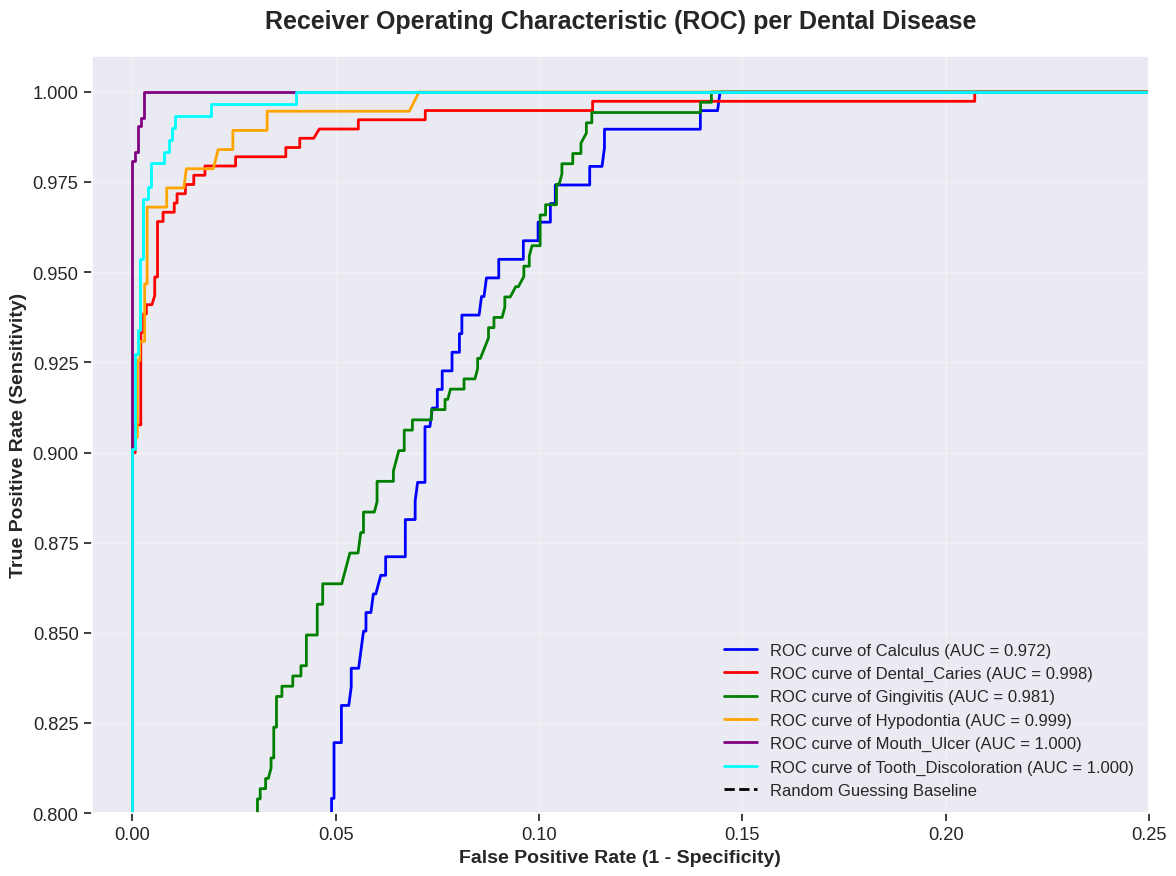

✅ ROC-AUC plot completed. (AUC > 0.9 is considered excellent in medical AI)


In [ ]:
# ==============================================================================
# CELL 7: MULTICLASS ROC-AUC ANALYSIS
# DESCRIPTION: Generates the Receiver Operating Characteristic (ROC) curve and
#              calculates the Area Under the Curve (AUC) for each disease class.
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("📊 Generating Clinical ROC-AUC Curves...")

# 1. Binarize labels dynamically based on the number of current classes (5 classes)
n_classes = len(CLASS_NAMES)
y_true_binarized = label_binarize(y_true, classes=range(n_classes))

# 2. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Plot all ROC curves
plt.figure(figsize=(12, 9))
colors = sns.color_palette("tab10", n_classes)  # ألوان ديناميكية على حسب عدد الكلاسات

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"ROC curve of {CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})",
    )

# Plot the random guessing baseline
plt.plot([0, 1], [0, 1], "k--", lw=2, label="Random Guessing Baseline")

# Expanded view to see the full curve properly
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=14, fontweight="bold")
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=14, fontweight="bold")
plt.title(
    "Receiver Operating Characteristic (ROC) per Dental Disease",
    fontsize=18,
    fontweight="bold",
    pad=20,
)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ ROC-AUC plot completed. (AUC > 0.9 is considered excellent in medical AI)")

### 🌌 t-SNE Feature Space Analysis
Here we prove that the EfficientNetB4 model is not memorizing the images, but rather learning distinct clinical features for each dental disease.

🧠 Extracting deep feature representations from the AI's 'brain'...
⏳ This might take a few seconds...
🌌 Projecting features into 2D space using t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


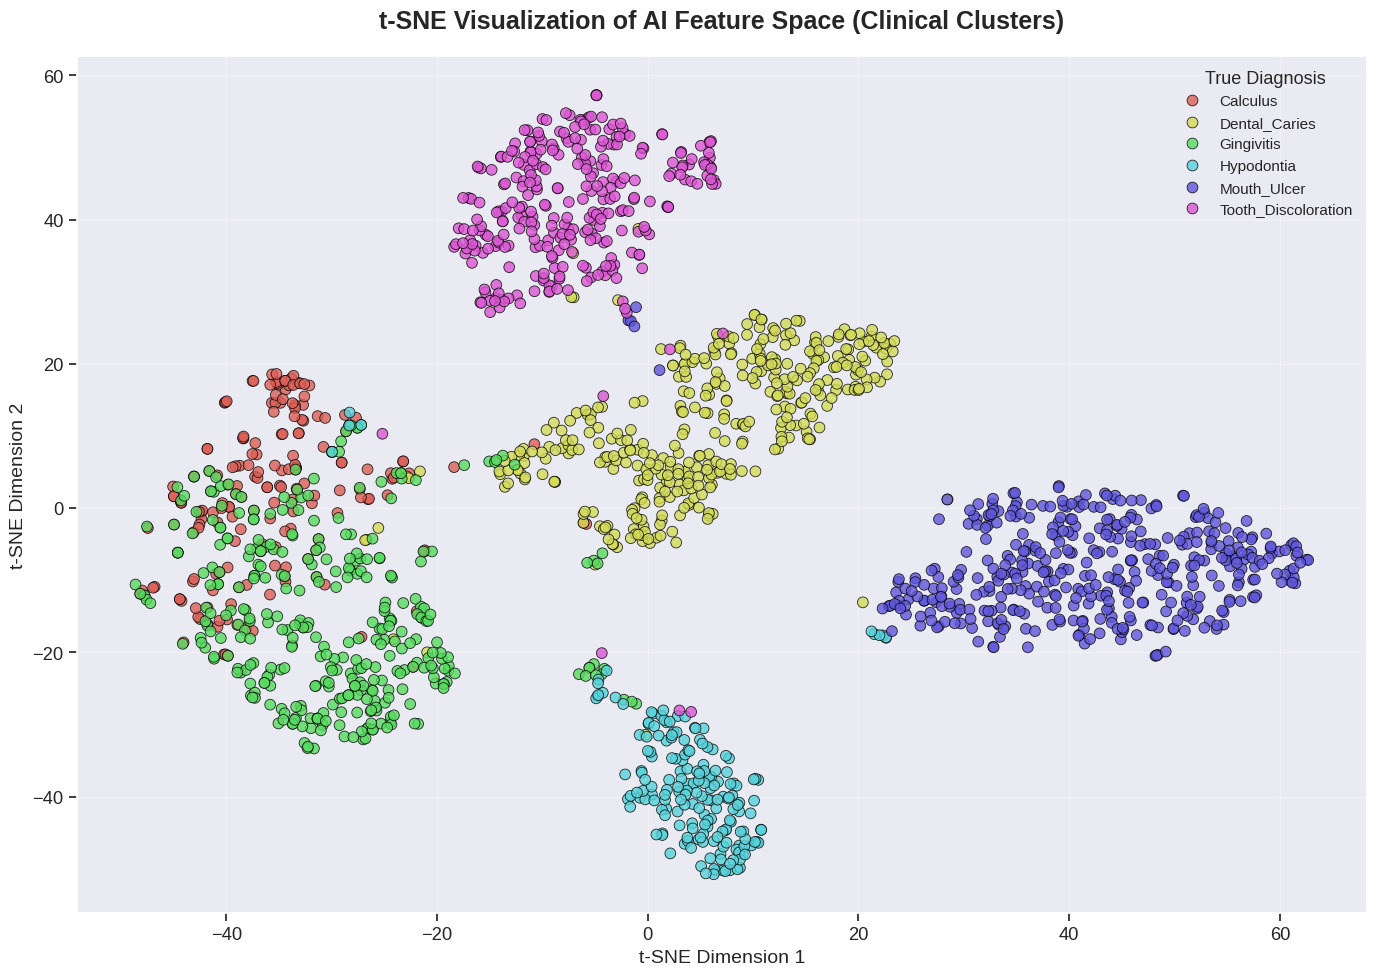

✅ t-SNE visualization completed. Notice how different diseases group together!


In [ ]:
# ==============================================================================
# CELL 8: DEEP FEATURE ABSTRACTION (t-SNE CLUSTERING)
# DESCRIPTION: Extracts high-level features from the penultimate layer of the
#              AI model and uses t-SNE to project them into a 2D space.
# ==============================================================================
import seaborn as sns
from sklearn.manifold import TSNE
import tensorflow as tf
import matplotlib.pyplot as plt

print("🧠 Extracting deep feature representations from the AI's 'brain'...")

# 1. Create a Feature Extractor Model (Taking the layer before classification)
feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.layers[-2].output)

# 2. Extract features
print("⏳ This might take a few seconds...")
val_generator.reset()  # Reset generator to ensure correct order
deep_features = feature_extractor.predict(val_generator, verbose=0)

# 3. Apply t-SNE for dimensionality reduction
print("🌌 Projecting features into 2D space using t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(deep_features)

# 4. Plot the results
print("🎨 Drawing the t-SNE plot...")
n_classes = len(CLASS_NAMES)  # 👈 السطر اللي كان ناقص

plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=[CLASS_NAMES[i] for i in y_true],
    palette=sns.color_palette("hls", n_classes),
    legend="full",
    alpha=0.8,
    s=60,
    edgecolor="k",
)

plt.title(
    "t-SNE Visualization of AI Feature Space (Clinical Clusters)",
    fontsize=18,
    fontweight="bold",
    pad=20,
)
plt.xlabel("t-SNE Dimension 1", fontsize=14)
plt.ylabel("t-SNE Dimension 2", fontsize=14)
plt.legend(title="True Diagnosis", title_fontsize="13", fontsize="11", loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ t-SNE visualization completed. Notice how different diseases group together!")

🩺 Analyzing AI Diagnostic Confidence Levels...


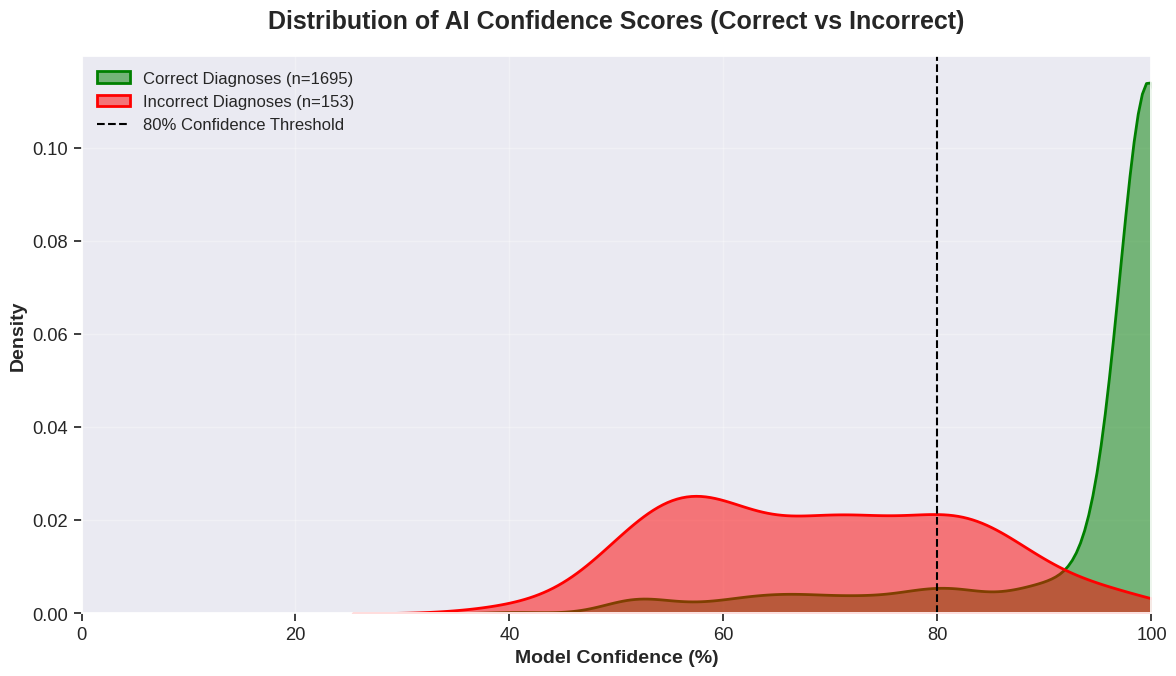

✅ Confidence analysis completed.
💡 Tip for Presentation: Emphasize that most correct diagnoses are clustered near 90-100% confidence!


In [ ]:
# ==============================================================================
# CELL 10: AI CONFIDENCE & RELIABILITY DISTRIBUTION
# DESCRIPTION: Analyzes the prediction probabilities to show how confident the
#              model is when it makes correct vs. incorrect diagnoses.
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("🩺 Analyzing AI Diagnostic Confidence Levels...")

# 1. Extract the maximum probability (confidence) for each prediction
confidences = np.max(predictions, axis=1) * 100

# 2. Separate into correct and incorrect predictions
correct_mask = (y_true == y_pred)
conf_correct = confidences[correct_mask]
conf_incorrect = confidences[~correct_mask]

# 3. Plot the distributions
plt.figure(figsize=(12, 7))

# KDE Plot for correct predictions (Green)
sns.kdeplot(conf_correct, fill=True, color="green", label=f"Correct Diagnoses (n={len(conf_correct)})", alpha=0.5, linewidth=2)

# KDE Plot for incorrect predictions (Red)
# Condition added in case the model is near perfect and has very few incorrect!
if len(conf_incorrect) > 0:
    sns.kdeplot(conf_incorrect, fill=True, color="red", label=f"Incorrect Diagnoses (n={len(conf_incorrect)})", alpha=0.5, linewidth=2)

plt.title('Distribution of AI Confidence Scores (Correct vs Incorrect)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Model Confidence (%)', fontsize=14, fontweight='bold')
plt.ylabel('Density', fontsize=14, fontweight='bold')
plt.xlim([0, 100])
plt.axvline(x=80, color='black', linestyle='--', label='80% Confidence Threshold')
plt.legend(loc='upper left', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Confidence analysis completed.")
print("💡 Tip for Presentation: Emphasize that most correct diagnoses are clustered near 90-100% confidence!")